# Homework 9 
## Average Reservoir Pressure


**Daniel McAllister-Ou**

---
Imports:

In [494]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pathlib
print(os.getcwd().split('\\')[-1])
sns.set_theme(context='notebook')

well_testing


Define Properties and Data: 

In [495]:
phi = 0.2
h = 25 # ft
rw = 0.25 # ft
A = 40 # acre
Bo = 1.17 # bbl/STB
mu_o = 2.24 # cp
ct = 10.2E-6 # 1/psi
q = 100 # stb/d for 90 days prior to shut-in 

In [496]:
data = pd.read_csv(r'hw9_data.csv',usecols=['Δt (hr)', 'p̄ws (psia)'])
data.head(10)

,Δt (hr),p̄ws (psia)
0,0.0000,2605.93
1,0.0010,2610.68
2,0.0021,2615.82
3,0.0034,2621.38
4,0.0048,2627.40
5,0.0064,2633.91
6,0.0082,2640.91
7,0.0102,2648.43
8,0.0125,2656.46
9,0.0151,2665.02


---
### Matthew-Brons-Haezebroek

Calculate Horner Time :

In [497]:
MBH_df = data.copy()
pwf = MBH_df['p̄ws (psia)'].iloc[0]
tp = 90 * 24 # hr
MBH_df['tp+Δt/Δt'] = (tp + MBH_df['Δt (hr)']) / MBH_df['Δt (hr)']
MBH_df['log10(tp+Δt/Δt)'] = np.log10(MBH_df['tp+Δt/Δt'])


Horner Plot : 

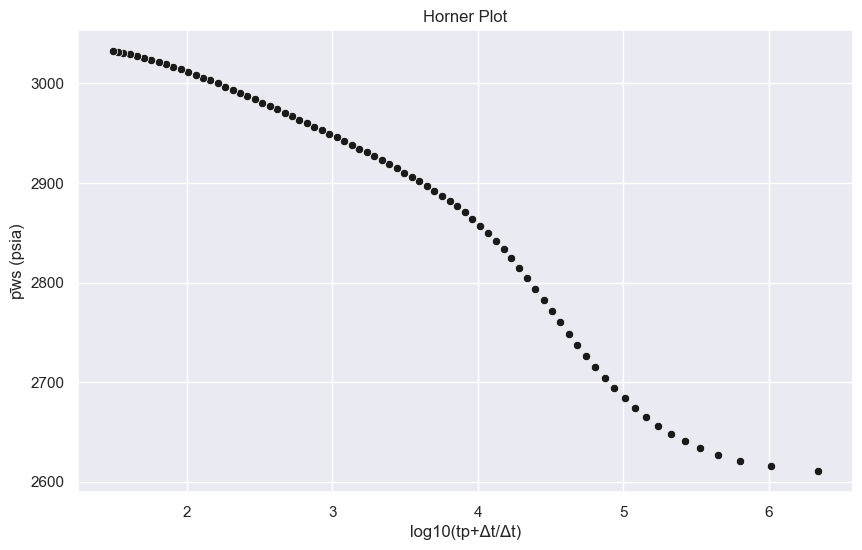

In [498]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='log10(tp+Δt/Δt)', y='p̄ws (psia)', data=MBH_df, color='k', ax=ax)
ax.set_title('Horner Plot')
plt.show()




Find Straight Line region : 

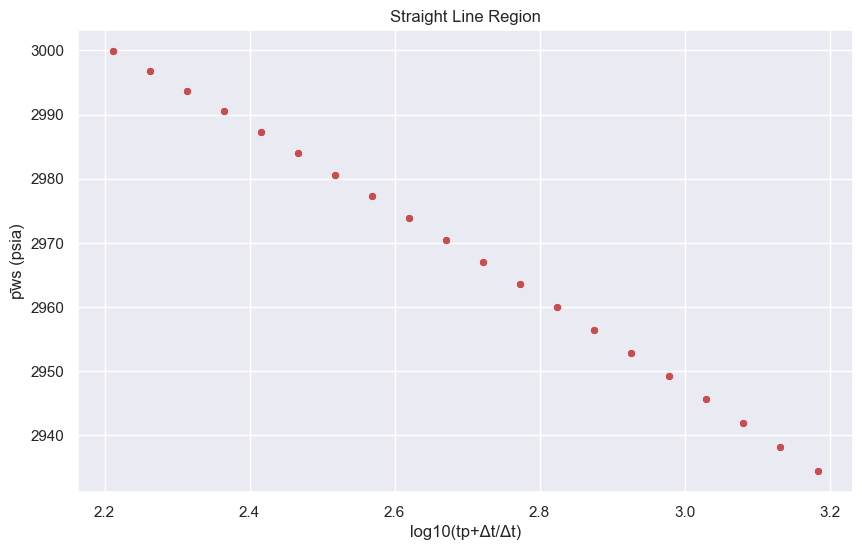

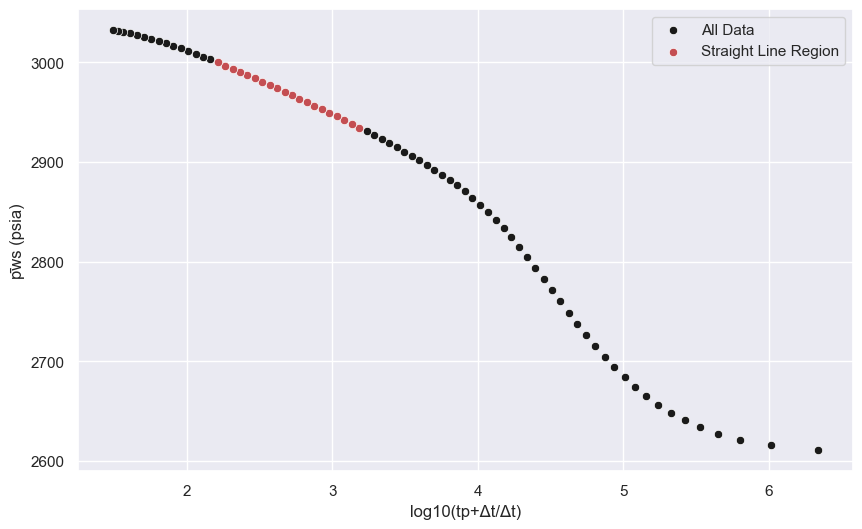

In [499]:
llim = 2.2
ulim = 3.2
straight_line_mask = (MBH_df['log10(tp+Δt/Δt)'] >= llim) & (MBH_df['log10(tp+Δt/Δt)'] <= ulim)
SL_MBH_df = MBH_df[straight_line_mask]
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='log10(tp+Δt/Δt)', y='p̄ws (psia)', data=SL_MBH_df, color='r', ax=ax)
ax.set_title('Straight Line Region')
plt.show()

fig,ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='log10(tp+Δt/Δt)', y='p̄ws (psia)', data=MBH_df, color='k', label='All Data', ax=ax)
sns.scatterplot(x='log10(tp+Δt/Δt)', y='p̄ws (psia)', data=SL_MBH_df, color='r', label='Straight Line Region', ax=ax)
plt.legend()
plt.show()


Fit Line and Find P* :

Slope: -67.40 psia/decade
Intercept / P_star: 3149.97 psia
MBH Min Time: 1.49 log10(hr)
MBH Max Time: 6.33 log10(hr)


<Axes: xlabel='log10(tp+Δt/Δt)', ylabel='p̄ws (psia)'>

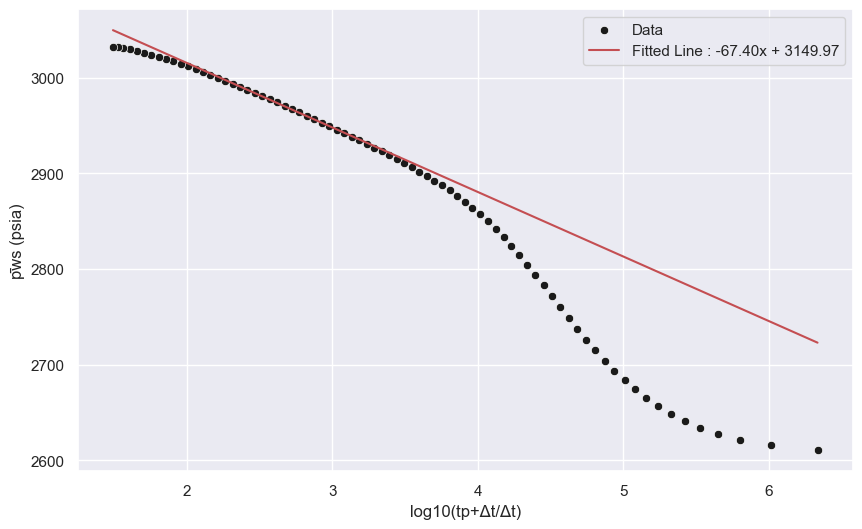

In [500]:
MBH_df = MBH_df[np.isfinite(MBH_df['log10(tp+Δt/Δt)'])]

MBH_slope, P_star = np.polyfit(SL_MBH_df['log10(tp+Δt/Δt)'], SL_MBH_df['p̄ws (psia)'], 1)
print(f'Slope: {MBH_slope:.2f} psia/decade')
print(f'Intercept / P_star: {P_star:.2f} psia')

MBH_min_time = MBH_df['log10(tp+Δt/Δt)'].min()
MBH_max_time = MBH_df['log10(tp+Δt/Δt)'].max()
print(f'MBH Min Time: {MBH_min_time:.2f} log10(hr)')
print(f'MBH Max Time: {MBH_max_time:.2f} log10(hr)')
line_x = np.linspace(MBH_min_time, MBH_max_time, 100)
# print(line_x)
line_y = MBH_slope * line_x + P_star

fig,ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='log10(tp+Δt/Δt)', y='p̄ws (psia)', data=MBH_df, color='k', label='Data', ax=ax)
sns.lineplot(x=line_x, y=line_y, color='r', label=f'Fitted Line : {MBH_slope:.2f}x + {P_star:.2f}', ax=ax)

Calculate K and S : 

In [501]:
k = -1 * 162.6 * q * mu_o * Bo / (MBH_slope * h)
print(f'Calculated Permeability: {k:.2f} md')

pws_1hr = MBH_slope * np.log10((tp + 1) / 1) + P_star
S = 1.151 * ((pws_1hr - pwf)/MBH_slope - np.log10(k/phi/mu_o/ct/rw**2) + 3.23)
print(f'Calculated Skin Factor: {S:.2f}')

Calculated Permeability: 25.29 md
Calculated Skin Factor: -10.88


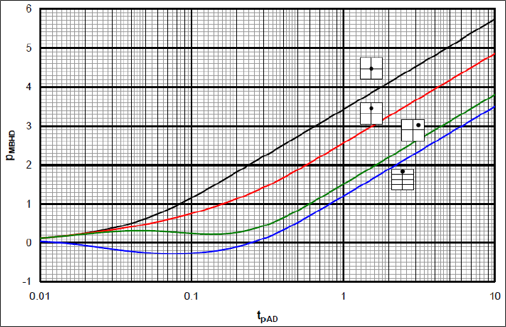

Calculate t_pAD : 

In [502]:
A = A * 43560 # ft^2

tpad = 0.0002637 * k * tp / phi / mu_o / ct / A
print(f'Calculated Dimensionless Time: {tpad:.2f}')

pmbhd = 4.0 # from plot above 
print(f'Calculated dimensionless pressure from MBH : {pmbhd:.2f}')

Calculated Dimensionless Time: 1.81
Calculated dimensionless pressure from MBH : 4.00


Calculate Pavg :

In [503]:
pav_MBH = P_star - MBH_slope / 2.303 * pmbhd
print(f'Calculated Average Pressure: {pav_MBH:.2f} psia')

Calculated Average Pressure: 3267.04 psia


---
### Ramey-Cobb

Define Shape factor for circular reservoir :

In [504]:
Ca = 31.6
tHav = Ca * tpad 
print(f'Calculated tHav : {tHav:.2f}')


Calculated tHav : 57.17


Calculate Pav

In [505]:
pav_RC = P_star - MBH_slope * np.log10(tHav)
print(f'Calculated Average Pressure: {pav_RC:.2f} psia')

Calculated Average Pressure: 3268.41 psia


---
### Dietz

Define Dietz data : 

In [506]:
dietz_df = data.copy()

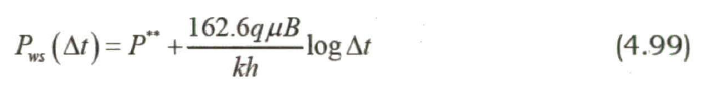

Plot MDH Semi-Log

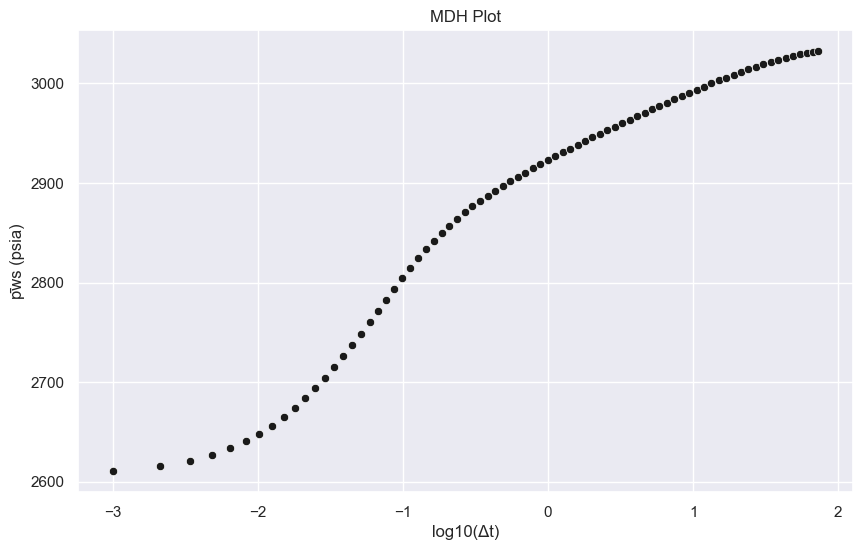

In [507]:
dietz_df = dietz_df[dietz_df['Δt (hr)'] > 0]
dietz_df['log10(Δt)'] = np.log10(dietz_df['Δt (hr)'])

fig,ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(x='log10(Δt)', y='p̄ws (psia)', data=dietz_df, color='k', ax=ax)
ax.set_title('MDH Plot');

Find Straight Line : 

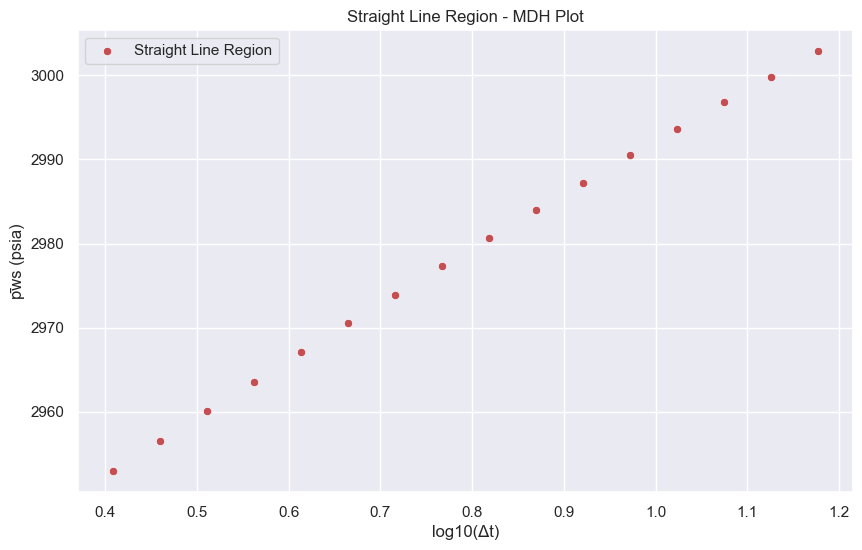

In [508]:
llim = 0.4
ulim = 1.2
straight_line_mask_dietz = (dietz_df['log10(Δt)'] >= llim) & (dietz_df['log10(Δt)'] <= ulim)
SL_dietz_df = dietz_df[straight_line_mask_dietz]

fig,ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='log10(Δt)', y='p̄ws (psia)', data=SL_dietz_df, color='r', label='Straight Line Region', ax=ax)
ax.set_title('Straight Line Region - MDH Plot');

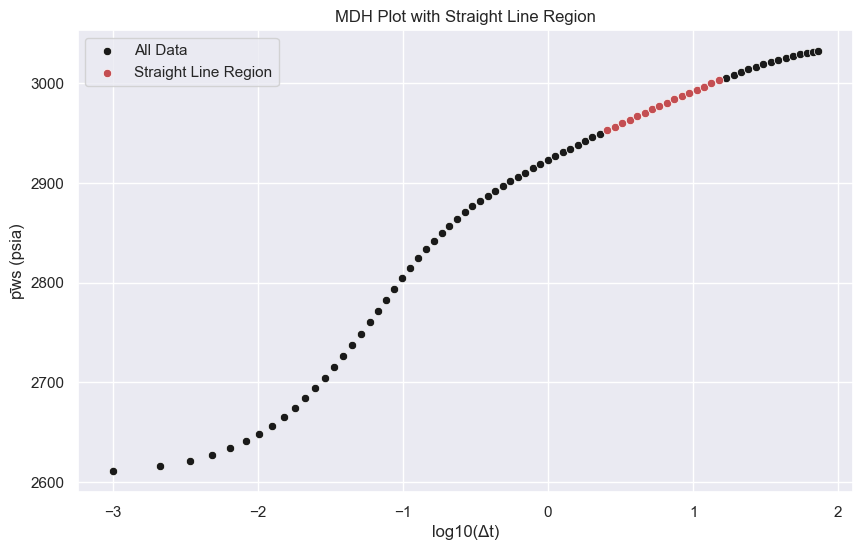

In [509]:
fig,ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='log10(Δt)', y='p̄ws (psia)', data=dietz_df, color='k',label='All Data', ax=ax)
sns.scatterplot(x='log10(Δt)', y='p̄ws (psia)', data=SL_dietz_df, color='r', label='Straight Line Region', ax=ax)
ax.set_title('MDH Plot with Straight Line Region');


Fit a line : 

MDH Slope: 65.16 psia/decade
MDH Intercept / P_star: 2926.93 psia


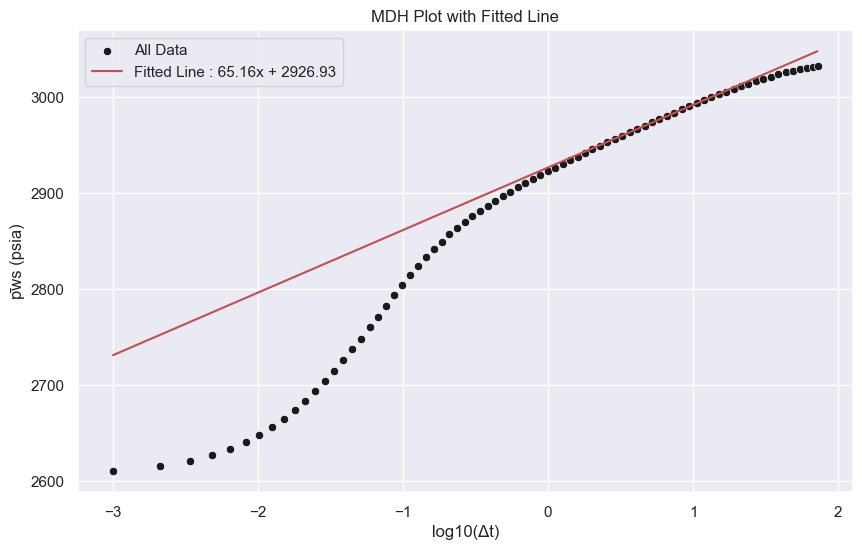

In [510]:
slope_MDH, P_star_MDH = np.polyfit(SL_dietz_df['log10(Δt)'], SL_dietz_df['p̄ws (psia)'], 1)
print(f'MDH Slope: {slope_MDH:.2f} psia/decade')
print(f'MDH Intercept / P_star: {P_star_MDH:.2f} psia')

MDH_min_time = dietz_df['log10(Δt)'].min()
MDH_max_time = dietz_df['log10(Δt)'].max()
line_x_MDH = np.linspace(MDH_min_time, MDH_max_time, 100)
line_y_MDH = slope_MDH * line_x_MDH + P_star_MDH
fig,ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='log10(Δt)', y='p̄ws (psia)', data=dietz_df, color='k',label='All Data', ax=ax)
sns.lineplot(x=line_x_MDH, y=line_y_MDH, color='r', label=f'Fitted Line : {slope_MDH:.2f}x + {P_star_MDH:.2f}', ax=ax)
ax.set_title('MDH Plot with Fitted Line');

Find k : 

In [511]:
k = 162.6 * q * mu_o * Bo / (slope_MDH * h)
print(f'Calculated Permeability from MDH: {k:.2f} md')

Calculated Permeability from MDH: 26.16 md


Find delta tpave and pave: 

Calculated Δtpave: 36.53 hr
Calculated average reservoir pressure: 3028.76 psia


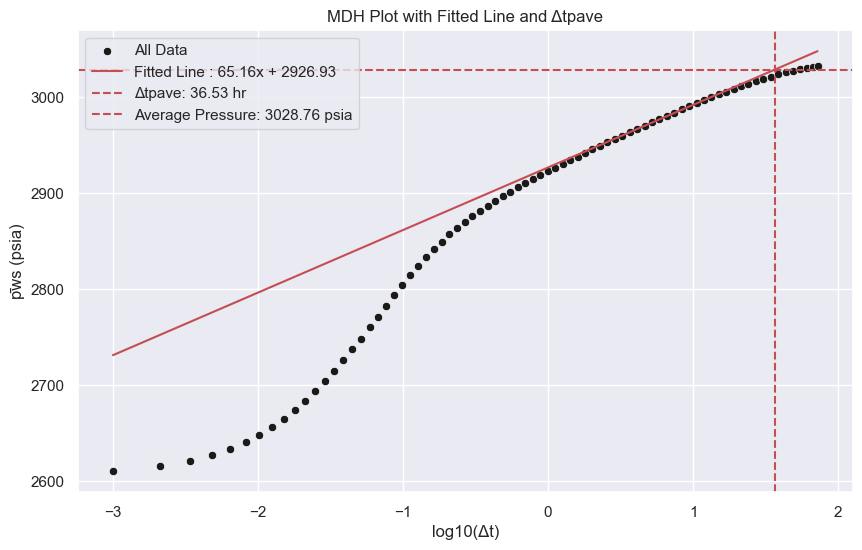

In [512]:
delta_tpave = phi * mu_o * ct * A / 0.0002637 / k / Ca 
pave = slope_MDH * np.log10(delta_tpave) + P_star_MDH
print(f'Calculated Δtpave: {delta_tpave:.2f} hr')
print(f'Calculated average reservoir pressure: {pave:.2f} psia')

fig,ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='log10(Δt)', y='p̄ws (psia)', data=dietz_df, color='k',label='All Data', ax=ax)
sns.lineplot(x=line_x_MDH, y=line_y_MDH, color='r', label=f'Fitted Line : {slope_MDH:.2f}x + {P_star_MDH:.2f}', ax=ax)
ax.axvline(x=np.log10(delta_tpave), color='r', linestyle='--', label=f'Δtpave: {delta_tpave:.2f} hr')
ax.axhline(y=pave, color='r', linestyle='--', label=f'Average Pressure: {pave:.2f} psia')
ax.legend(loc='upper left')
ax.set_title('MDH Plot with Fitted Line and Δtpave')
plt.show();

---
### Saphir 

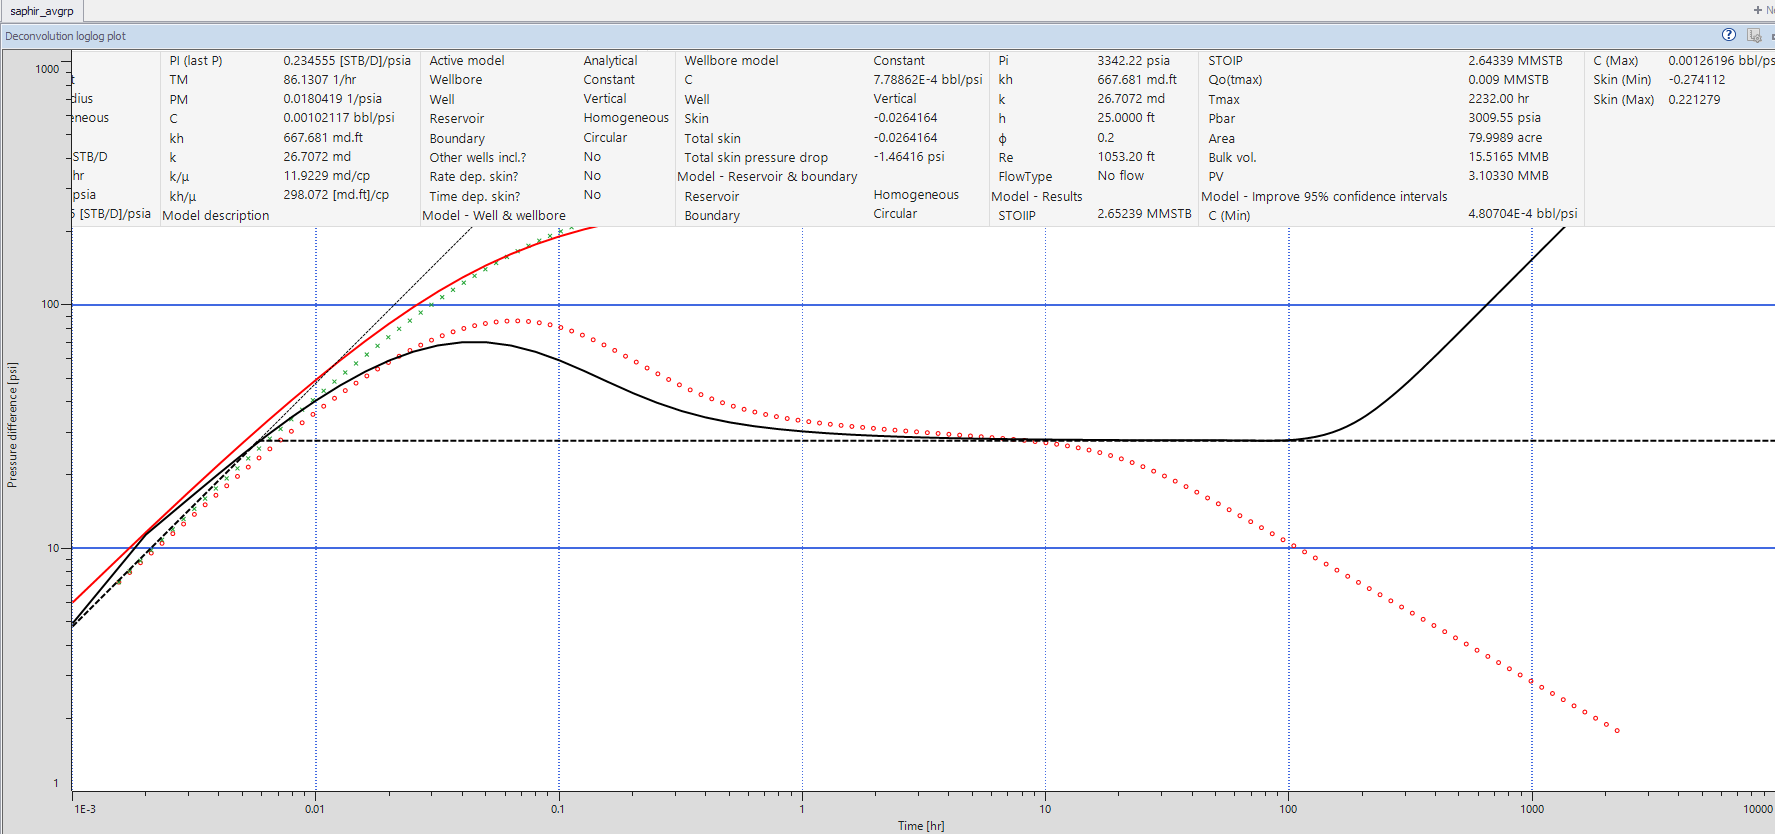

Average Pressure from Saphir is 3009.5